In [12]:
import torch 
torch.cuda.is_available()

True

In [13]:
import sys
sys.path.append('../../utils')
from functions import * 

In [14]:
from importlib import reload
import sys

# Path to the Leaflet repository
PATH_TO_LEAFLET_REPO = '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/'
sys.path.append(PATH_TO_LEAFLET_REPO)

In [15]:
import pyro
import pyro.distributions as dist
from pyro.infer.autoguide import AutoDiagonalNormal, AutoGuideList, AutoDelta, AutoMultivariateNormal
from pyro.infer import SVI, Trace_ELBO, RenyiELBO, Predictive
from pyro.distributions import constraints
import matplotlib.pyplot as plt
import math

In [16]:
from importlib import reload
#from load_cluster_data import load_cluster_data
from betabinomo_mix_singlecells import *
#reload(betabinomo_mix_singlecells)
from cell_state_asign_consistency import *
#reload(cell_state_asign_consistency)
import load_cluster_data

import torch
import sklearn.manifold 
import plotnine as p9
import time
# indicate plot should be small 4 by 4
import plotnine as p9
from plotnine import ggplot, geom_point, aes, stat_smooth, facet_wrap, geom_violin, theme, element_blank, geom_text, geom_bar, geom_hline
import plotnine
from tqdm import tqdm
plotnine.options.figure_size = (4, 4)
import seaborn as sns
sns.set_theme(style="whitegrid")

In [17]:
def quick_clust_plot(clust, simple_data):
    simple_data_junc = simple_data[simple_data["Cluster"] == clust]
    # make violin plot with jitter 
    print(simple_data_junc.cell_type.value_counts())
    print(simple_data_junc.gene_id.unique())
    print(simple_data_junc.junction_id.unique())
    plt.figuresize=(6, 6)
    sns.violinplot(data = simple_data_junc, x = "juncratio", y = "cell_type", hue="junction_id_index")
    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title 
    plt.title("cluster:" + str(clust), fontsize=16)
    # set x axis label to "Junction Usage Ratio (PSI)"
    plt.xlabel("Junction Usage Ratio (PSI)", fontsize=20)
    plt.ylabel("Cell Type Group", fontsize=20)
    # increase x and y tick label size to 14
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.show()

### Settings and Load data

In [18]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

K = 50 # set to very high number 

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

hypers = {
    "eta" : 1./K, 
    "alpha_prior" : 1, # karin had 0.65 
    "pi_prior" : 1 
}

print(hypers["eta"])

cuda
0.02


In [19]:
# this folder contains input data for each tissue cell type sample
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/'
#input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisMuscle/muscle/'

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, has_genes="yes") 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# still do preprocessing in scipy
import scipy.sparse as sp
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])
print(cluster_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/


Finished reading in data from folder ...
['Brain_Non-Myeloid_brain_pericyte'
 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell'
 'Brain_Non-Myeloid_Bergmann_glial_cell'
 'Brain_Non-Myeloid_endothelial_cell' 'Brain_Non-Myeloid_oligodendrocyte'
 'Brain_Non-Myeloid_neuron' 'Brain_Myeloid_macrophage'
 'Brain_Myeloid_microglial_cell' 'Brain_Non-Myeloid_astrocyte']
7856
16206
The maximum junction count was initially:  150346
80
The maximum junction count is now:  4982
                                             cell_id  Cluster  Cluster_Counts  \
0  A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...        4              21   
1  A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...        4              21   
2  A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...       10              16   
3  A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...       27               7   
4  A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...       28              12   

             junction_id        gene_id  junc

In [20]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

The number of cells going into training data is:
7856
7856


In [21]:
simple_data = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]
# get true PSI for each Cluster 
simple_data.head()

,cell_id_index,Cluster,cell_type,junction_id_index,juncratio,junc_count,cluster_count,junction_id,gene_id
0,0,4,Brain_Non-Myeloid_brain_pericyte,0,0.523810,11.0,21,1_160044753_160070699,4930523C07Rik
1,0,4,Brain_Non-Myeloid_brain_pericyte,1,0.476190,10.0,21,1_160070803_160075030,4930523C07Rik
2,0,10,Brain_Non-Myeloid_brain_pericyte,2,1.000000,16.0,16,1_155567681_155572197,Acbd6
3,0,27,Brain_Non-Myeloid_brain_pericyte,3,1.000000,7.0,7,1_36307836_36316208,Arid5a
4,0,28,Brain_Non-Myeloid_brain_pericyte,4,0.416667,5.0,12,1_36316327_36317609,Arid5a


In [22]:
simple_data.Cluster.unique()

array([   4,   10,   27, ..., 5172, 9599,  191])

Brain_Non-Myeloid_endothelial_cell                  537
Brain_Non-Myeloid_brain_pericyte                    408
Brain_Non-Myeloid_astrocyte                          72
Brain_Non-Myeloid_oligodendrocyte                    66
Brain_Non-Myeloid_neuron                             27
Brain_Non-Myeloid_oligodendrocyte_precursor_cell     21
Brain_Myeloid_microglial_cell                        18
Name: cell_type, dtype: int64
['4930523C07Rik']
['1_160044753_160070699' '1_160070803_160075030' '1_160044753_160075030']


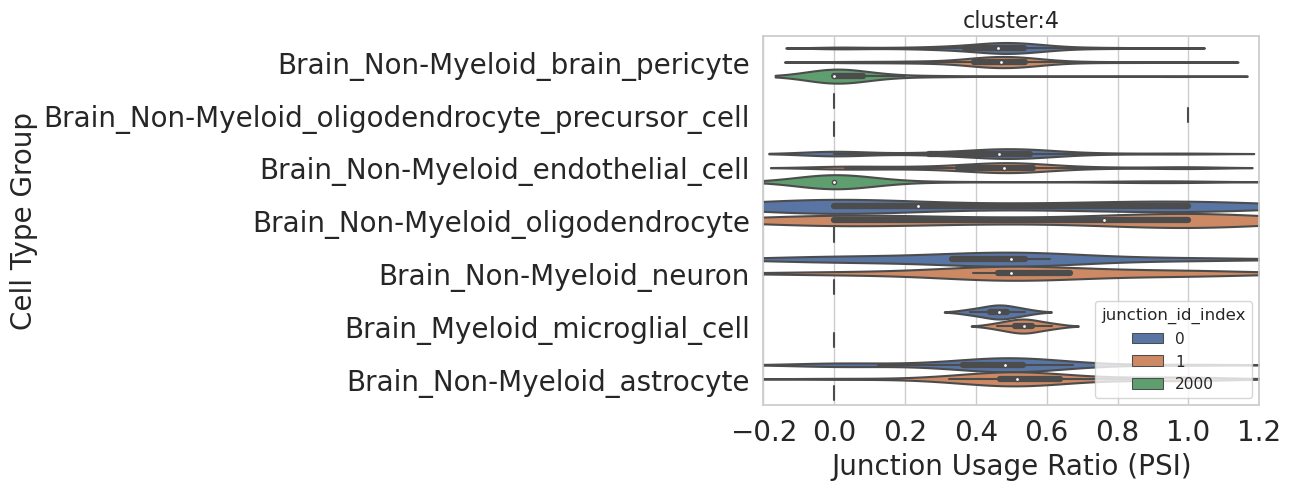

In [24]:
# let's visualize junction usage ratios for a given custer 
clust = 4 
quick_clust_plot(clust, simple_data)

In [25]:
def my_log_prob(y_sparse, total_counts_sparse, pred):
    
    # Extract non-zero elements and their indices from y and total_counts
    y_indices = y_sparse._indices()
    y_values = y_sparse._values()

    total_counts_indices = total_counts_sparse._indices()
    total_counts_values = total_counts_sparse._values()

    # Ensure that y and total_counts align on the same indices
    assert torch.equal(y_indices, total_counts_indices)

    # Compute log probabilities at these indices
    log_probs = dist.Binomial(total_counts_values, pred[y_indices[0], y_indices[1]]).log_prob(y_values)

    # Sum the log probabilities
    return log_probs.sum()

In [26]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

def model(y, total_counts, K):
    N, P = y.shape

    a = pyro.sample("a", dist.Gamma(1., 1.).expand([P]).to_event(1))
    b = pyro.sample("b", dist.Gamma(1., 1.).expand([P]).to_event(1))

    psi_dist = dist.Beta(a, b).expand([K, P]).to_event(2)
    psi = pyro.sample("psi", psi_dist)

    pi = pyro.sample("pi", dist.Dirichlet(torch.ones(K) / K))
    conc = pyro.sample("conc", dist.Gamma(1, 1))

    with pyro.plate('data1', N):
        assign_dist = dist.Dirichlet(pi * conc)
        assign = pyro.sample("assign", assign_dist)

    pred = torch.mm(assign, psi)

    # Use custom log probability
    log_prob = my_log_prob(y, total_counts, pred) # double check that I am not double summing here 
    pyro.factor("obs", log_prob.sum())
    #pyro.factor("obs", log_prob)

In [27]:
def fit(y, total_counts, K, guide, patience=10, min_delta=0.01, lr=0.05, num_epochs=500):
    adam = pyro.optim.Adam({"lr": lr})
    svi = SVI(model, guide, adam, loss=Trace_ELBO())
    pyro.clear_param_store()
    losses = []
    best_loss = float('inf')
    epochs_since_improvement = 0

    for j in range(num_epochs):
        loss = svi.step(y, total_counts, K)
        losses.append(loss)

        # Check for improvement
        if best_loss - loss > min_delta:
            best_loss = loss
            epochs_since_improvement = 0
        else:
            epochs_since_improvement += 1

        # Early stopping check
        if epochs_since_improvement >= patience:
            print(f"Stopping early at epoch {j}")
            break

        if j % 10 == 0:
            print(f"Epoch {j}, Loss: {loss}")

        #torch.cuda.empty_cache()  # Attempt to free unused memory
    return losses

In [28]:
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [29]:
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [30]:
K = 50 # num factors
J = len(total_counts_tensor[0])
C = len(total_counts_tensor)
print(C, J, K)

guide = AutoDiagonalNormal(model)
print(guide)

7856 15945 50
AutoDiagonalNormal()


Epoch 0, Loss: 267138204.40194386
Epoch 10, Loss: 153049149.83886537
Epoch 20, Loss: 102102649.03999984
Epoch 30, Loss: 79239074.73872256
Epoch 40, Loss: 69357510.20712137
Epoch 50, Loss: 64893147.49246335
Epoch 60, Loss: 62569002.230528355
Epoch 70, Loss: 61102682.3902843
Epoch 80, Loss: 60110118.365341425
Epoch 90, Loss: 59373234.01229882
Epoch 100, Loss: 58786150.08938241
Epoch 110, Loss: 58307407.30667114
Epoch 120, Loss: 57909255.00104737
Epoch 130, Loss: 57559569.12574363
Epoch 140, Loss: 57257862.26146722
Epoch 150, Loss: 56992854.120500565
Epoch 160, Loss: 56759600.03321338
Epoch 170, Loss: 56548545.70169997
Epoch 180, Loss: 56359417.9490273
Epoch 190, Loss: 56208056.51163244


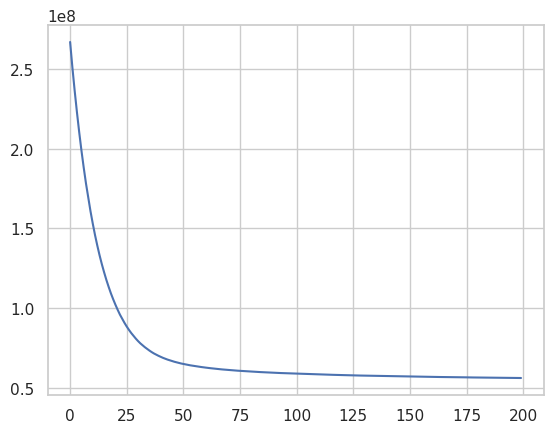

In [31]:
losses = fit(y_tensor, total_counts_tensor, K, guide, lr=0.1, num_epochs=200)
plt.plot(losses, label = "Diagonal variational posterior")

In [32]:
# Sample from the guide (posterior)
guide_trace = pyro.poutine.trace(guide).get_trace(y_tensor, total_counts_tensor, K)

In [33]:
# Extract the latent variables
latent_vars = {name: node["value"].detach().cpu().numpy() for name, node in guide_trace.nodes.items() if node["type"] == "sample"}

In [34]:
latent_vars["conc"]

array(8.293668, dtype=float32)

In [35]:
# can we plot assign probabilityies for each cell
assign_post = latent_vars["assign"]
assign_post

array([[4.21570439e-04, 2.21649316e-04, 1.87399378e-03, ...,
        5.57384678e-14, 6.31851396e-13, 3.43921582e-16],
       [2.59662280e-04, 8.60709406e-05, 1.17021479e-01, ...,
        8.82425478e-16, 2.42959786e-13, 6.95133387e-18],
       [3.19790270e-04, 2.61570024e-03, 8.02995462e-04, ...,
        4.55272020e-18, 1.00776836e-13, 2.35274439e-16],
       ...,
       [1.76718488e-01, 6.47669483e-04, 2.61419656e-04, ...,
        2.35393476e-11, 4.58511344e-08, 1.89285423e-08],
       [1.25279026e-02, 2.97492538e-02, 8.10386315e-02, ...,
        1.05351307e-06, 2.40825759e-09, 4.69201353e-08],
       [6.15742654e-02, 3.26073617e-02, 1.00851238e-01, ...,
        4.02314890e-06, 2.95003910e-09, 1.10104729e-11]], dtype=float32)

In [36]:
# Step 1: Run UMAP
import umap
reducer = umap.UMAP()
embedding = reducer.fit_transform(assign_post)  # Reducing to 2 dimensions

In [37]:
# Step 2: Prepare cell type labels for coloring
cell_types = cell_ids_conversion['cell_type'].tolist()

Brain_Myeloid_microglial_cell                       4394
Brain_Non-Myeloid_oligodendrocyte                   1574
Brain_Non-Myeloid_endothelial_cell                   715
Brain_Non-Myeloid_astrocyte                          432
Brain_Non-Myeloid_neuron                             281
Brain_Non-Myeloid_oligodendrocyte_precursor_cell     203
Brain_Non-Myeloid_brain_pericyte                     156
Brain_Myeloid_macrophage                              61
Brain_Non-Myeloid_Bergmann_glial_cell                 40
Name: cell_type, dtype: int64


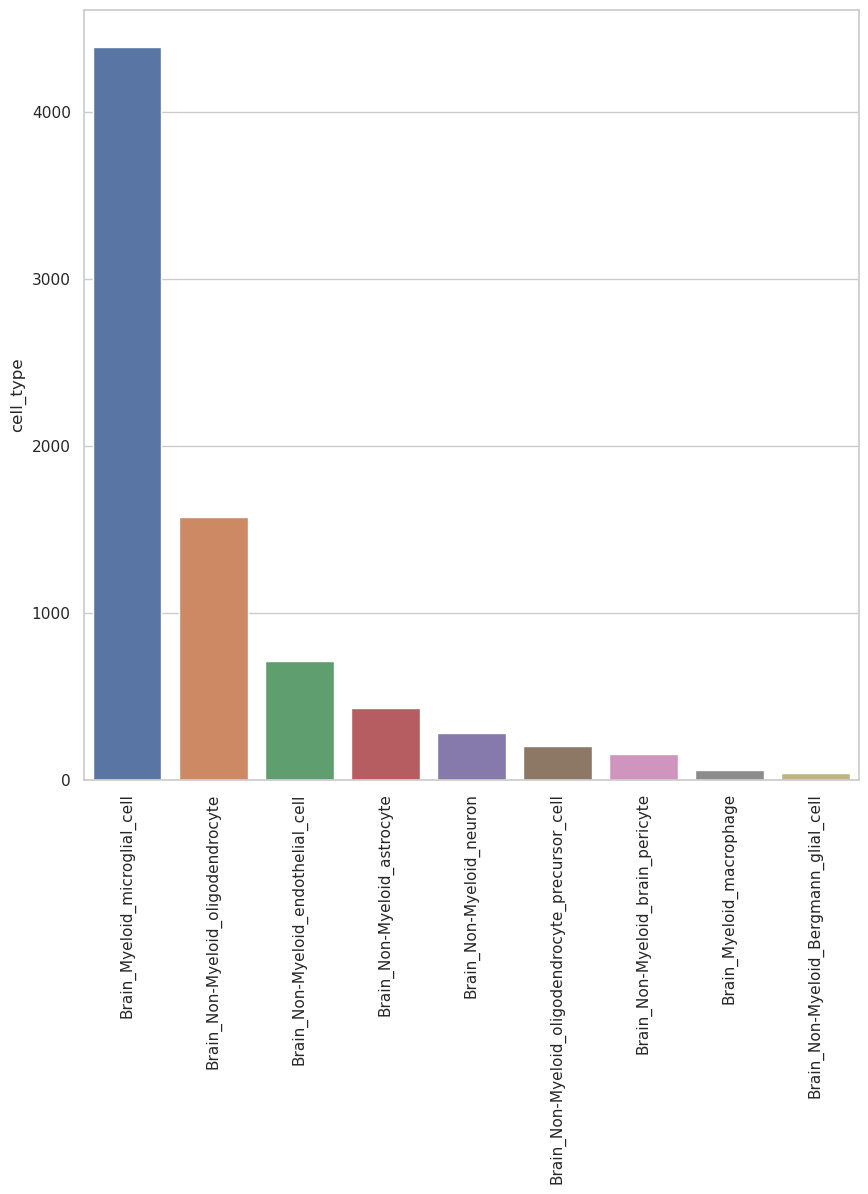

In [38]:
print(cell_ids_conversion.cell_type.value_counts())
# make a barplot of cell type counts
plt.figure(figsize=(10, 10))
sns.barplot(x = cell_ids_conversion.cell_type.value_counts().index, y = cell_ids_conversion.cell_type.value_counts())
plt.xticks(rotation=90)
plt.show()

In [39]:
top_three_cell_types = cell_ids_conversion.cell_type.value_counts()[0:5].index.values
cell_types = cell_ids_conversion['cell_type'].apply(lambda x: x if x in top_three_cell_types else 'Other').tolist()

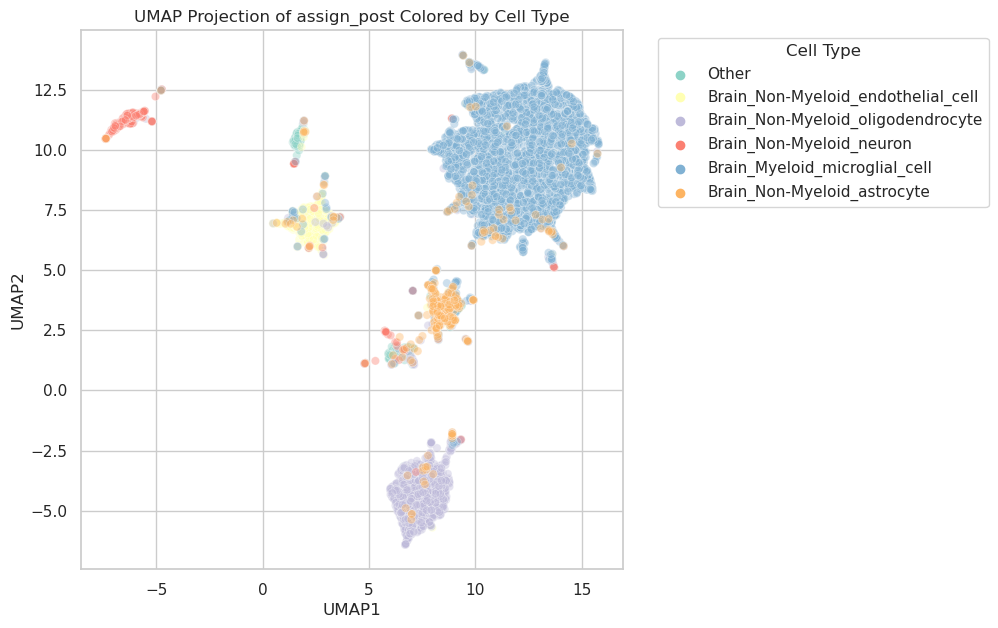

In [40]:
# Plotting
plt.figure(figsize=(7, 7))
sns.scatterplot(
    x=embedding[:, 0], 
    y=embedding[:, 1], 
    hue=cell_types,
    alpha=0.4,
    palette=sns.color_palette("Set3", len(top_three_cell_types) + 1),  # +1 for 'Other' category
    legend='full'
)
plt.title("UMAP Projection of assign_post Colored by Cell Type")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

In [55]:
# convert latent_vars["assign"] to pandas dataframe
assign_post_df = pd.DataFrame(assign_post)
assign_post_df.columns = ["factor_" + str(x) for x in assign_post_df.columns]   
assign_post_df.head()

,factor_0,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7,factor_8,factor_9,...,factor_40,factor_41,factor_42,factor_43,factor_44,factor_45,factor_46,factor_47,factor_48,factor_49
0,0.000422,0.000222,0.001874,0.000296,0.000140,0.000036,0.015154,0.000104,0.000069,0.015934,...,7.853793e-07,2.836058e-08,4.644052e-05,6.002027e-05,2.905631e-07,9.226453e-14,7.948794e-12,5.573847e-14,6.318514e-13,3.439216e-16
1,0.000260,0.000086,0.117021,0.000214,0.000529,0.003660,0.001591,0.000170,0.000002,0.000617,...,5.223322e-08,5.856660e-08,1.775854e-09,5.530000e-08,6.821553e-08,1.214879e-09,1.675887e-11,8.824255e-16,2.429598e-13,6.951334e-18
2,0.000320,0.002616,0.000803,0.070698,0.000001,0.000156,0.011185,0.001523,0.000481,0.006904,...,4.642114e-04,1.737206e-03,9.962444e-05,6.453561e-07,6.558240e-11,5.273877e-09,1.283913e-08,4.552720e-18,1.007768e-13,2.352744e-16
3,0.000097,0.000079,0.069077,0.001120,0.000030,0.000011,0.007544,0.000121,0.000062,0.000134,...,1.876126e-08,2.857973e-09,1.050594e-06,8.244046e-06,1.852308e-09,2.038461e-14,4.914168e-09,7.486767e-13,3.828247e-11,5.122553e-10
4,0.000064,0.000246,0.002639,0.000072,0.000026,0.000275,0.001303,0.000037,0.000116,0.000717,...,2.854500e-10,9.501058e-10,1.291022e-07,1.069828e-10,8.199903e-09,3.051811e-09,1.440995e-09,5.749521e-10,1.300290e-14,1.993103e-17


In [60]:
# get factor sums column wise 
factor_sums = assign_post_df.sum(axis=0)
# order factors by sums
factor_sums.sort_values(ascending=False, inplace=True)
# get top 10 factors
top_factors = factor_sums.index[0:10]
top_factors

Index(['factor_9', 'factor_8', 'factor_13', 'factor_16', 'factor_7',
       'factor_0', 'factor_18', 'factor_6', 'factor_17', 'factor_2'],
      dtype='object')

(array([2.344e+03, 3.380e+02, 2.060e+02, 1.600e+02, 1.040e+02, 8.600e+01,
        8.200e+01, 6.200e+01, 5.500e+01, 3.800e+01, 5.800e+01, 4.200e+01,
        3.200e+01, 4.000e+01, 3.100e+01, 3.900e+01, 4.300e+01, 3.300e+01,
        4.100e+01, 3.900e+01, 4.000e+01, 3.500e+01, 4.600e+01, 5.400e+01,
        4.900e+01, 5.600e+01, 6.600e+01, 4.400e+01, 5.600e+01, 7.100e+01,
        7.200e+01, 5.400e+01, 6.800e+01, 7.600e+01, 6.600e+01, 7.900e+01,
        8.200e+01, 7.600e+01, 7.600e+01, 8.500e+01, 9.000e+01, 9.700e+01,
        8.000e+01, 9.300e+01, 9.000e+01, 1.010e+02, 9.800e+01, 9.000e+01,
        1.030e+02, 9.500e+01, 9.700e+01, 1.070e+02, 9.700e+01, 8.200e+01,
        1.070e+02, 8.800e+01, 8.300e+01, 9.100e+01, 7.800e+01, 5.700e+01,
        8.100e+01, 5.800e+01, 6.600e+01, 6.200e+01, 6.600e+01, 4.400e+01,
        5.500e+01, 4.500e+01, 3.700e+01, 3.400e+01, 4.000e+01, 3.300e+01,
        2.700e+01, 3.000e+01, 2.300e+01, 2.200e+01, 1.800e+01, 1.800e+01,
        1.400e+01, 1.200e+01, 1.000e+0

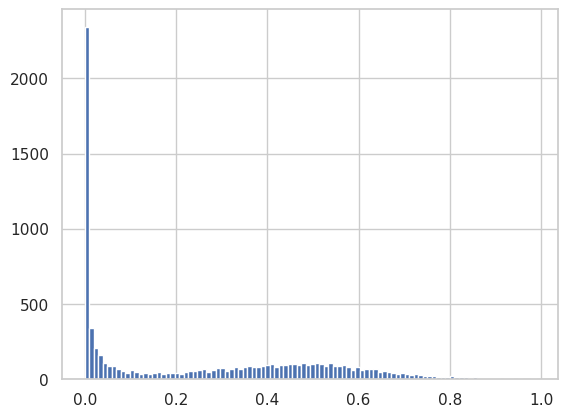

In [61]:
plt.hist(assign_post_df[top_factors[0]], bins=100)

Text(0.5, 1.0, 'assign_post values across ALL factors')

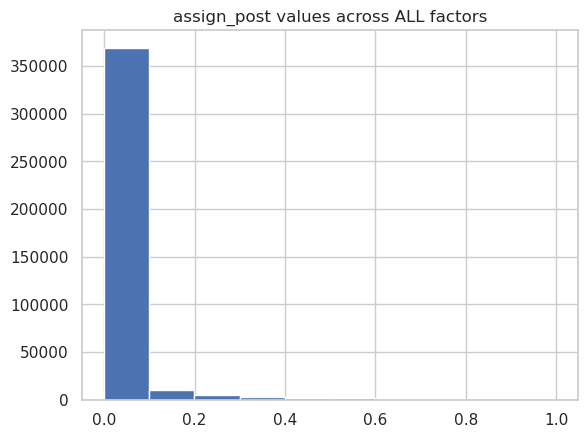

In [57]:
plt.hist(latent_vars["assign"].flatten())
# add title 
plt.title("assign_post values across ALL factors")

In [42]:
top_three_cell_types_list = list(top_three_cell_types)
top_three_cell_types_list

['Brain_Myeloid_microglial_cell',
 'Brain_Non-Myeloid_oligodendrocyte',
 'Brain_Non-Myeloid_endothelial_cell',
 'Brain_Non-Myeloid_astrocyte',
 'Brain_Non-Myeloid_neuron']

In [43]:
# Create a color palette for the cell types
cell_type_palette = sns.color_palette("hsv", len(top_three_cell_types_list) + 1)

# Map cell types to colors
row_colors = [cell_type_palette[top_three_cell_types_list.index(ct)] if ct in top_three_cell_types_list else cell_type_palette[-1] for ct in cell_types]

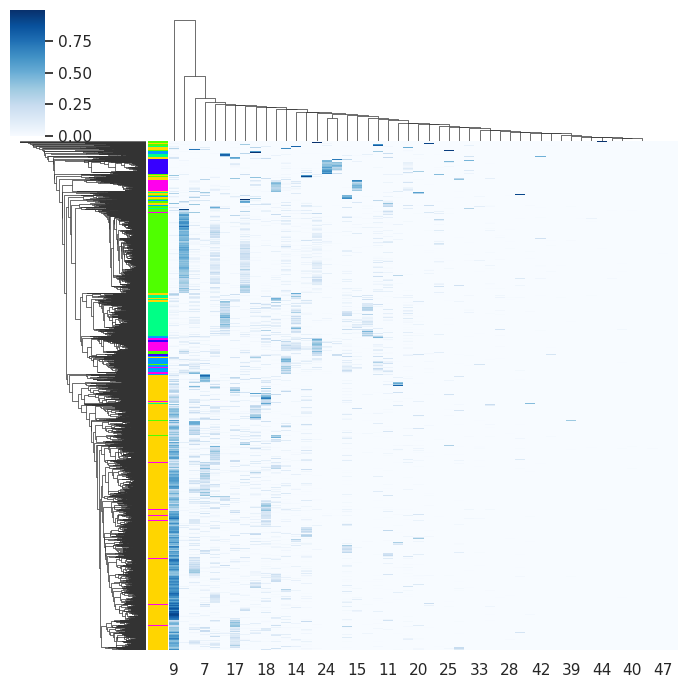

In [44]:
# Generate the clustermap with row colors
sns.clustermap(assign_post, cmap="Blues", figsize=(7, 7),
              row_colors=row_colors,  # Using a list instead of a DataFrame
               yticklabels=False)  # Hide y-axis labels for clarity

plt.show()

In [45]:
# compare to autoencoder (within pyro?) ?Sophia? 
# VAE in pyro afterwards... (with a binomial loss on the end) along the lines of this model 
# run original code on simulated data and compare to current code 

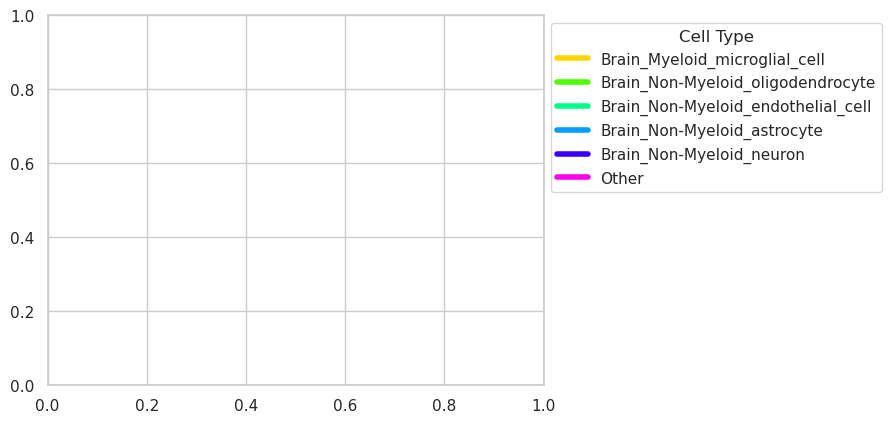

In [46]:
# Create a custom legend for the cell types
# Here, we use the cell_type_palette and top_three_cell_types
legend_handles = [plt.Line2D([0], [0], color=color, lw=4) for color in cell_type_palette]
legend_labels = top_three_cell_types_list + ['Other']

# Add the legend to the plot
plt.legend(handles=legend_handles, labels=legend_labels, title='Cell Type',
           bbox_to_anchor=(1, 1), loc='upper left')